# NN with Keras and TensorFlow using GradientTape()

#### Importing libraries

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

#### Generating data

In [2]:
X_raw, y_raw = make_moons(n_samples=1200, noise=0.2, random_state=42)
X_raw = X_raw.astype(np.float32)
y_raw = y_raw.reshape(-1, 1).astype(np.float32)

#### Split the Data using train_test_split()
#### Step A: Separate 15% for the final TEST set (remaining 85% for train + val)

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(X_raw, y_raw, test_size=0.15, random_state=42, stratify=y_raw)

#### Step B: From the remaining 85%, separate about 18% for VALIDATION 
#### that gives the exact ratio 70% Train, 15% Val, 15% Test

In [5]:
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp) 

In [6]:
print(f"Train set: {X_train.shape[0]} samples")
print(f"Val set:   {X_val.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples\n")

Train set: 840 samples
Val set:   180 samples
Test set:  180 samples



#### Packing into tf.data.Dataset batches
#### Shuffling train dataset only

In [7]:
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(buffer_size=1024).batch(BATCH_SIZE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE)

#### Making NN model

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

c:\Users\87vla\miniconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Learning rate schedule, optimizer and loss function

In [11]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.01,
    decay_steps=1000,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
loss_fn = tf.keras.losses.BinaryCrossentropy()

## Training loop with GradientTape()

#### Building the metric for accuracy

In [12]:
train_accuracy = tf.keras.metrics.BinaryAccuracy()
val_accuracy = tf.keras.metrics.BinaryAccuracy()

#### Training and Validation functions with GradientTape

In [13]:
@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        predictions = model(x_batch, training=True)
        loss = loss_fn(y_batch, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_accuracy.update_state(y_batch, predictions)
    return loss

In [14]:
@tf.function
def val_step(x_batch, y_batch):
    predictions = model(x_batch, training=False)
    loss = loss_fn(y_batch, predictions)
    val_accuracy.update_state(y_batch, predictions)
    return loss

#### Main loop with N Epochs

In [15]:
EPOCHS = 50
for epoch in range(EPOCHS):
    train_loss = 0.0
    train_batches = 0
    val_loss = 0.0
    val_batches = 0
    
    train_accuracy.reset_state()
    
    for x_batch, y_batch in train_dataset:
        loss = train_step(x_batch, y_batch)
        train_loss += loss.numpy()
        train_batches += 1
        
    val_accuracy.reset_state()
    
    for x_batch, y_batch in val_dataset:
        v_loss = val_step(x_batch, y_batch)
        val_loss += v_loss.numpy()
        val_batches += 1
        
    print(f"Epoch {epoch + 1}/{EPOCHS}, "
          f"Train Loss: {train_loss / train_batches:.4f}, "
          f"Train Accuracy: {train_accuracy.result().numpy():.4f}, "
          f"Val Loss: {val_loss / val_batches:.4f}, "
          f"Val Accuracy: {val_accuracy.result().numpy():.4f}")

Epoch 1/50, Train Loss: 0.4097, Train Accuracy: 0.8321, Val Loss: 0.3727, Val Accuracy: 0.8500
Epoch 2/50, Train Loss: 0.2711, Train Accuracy: 0.8821, Val Loss: 0.3295, Val Accuracy: 0.8611
Epoch 3/50, Train Loss: 0.2253, Train Accuracy: 0.9048, Val Loss: 0.2864, Val Accuracy: 0.8611
Epoch 4/50, Train Loss: 0.1886, Train Accuracy: 0.9321, Val Loss: 0.2398, Val Accuracy: 0.8889
Epoch 5/50, Train Loss: 0.1651, Train Accuracy: 0.9333, Val Loss: 0.2667, Val Accuracy: 0.8833
Epoch 6/50, Train Loss: 0.1329, Train Accuracy: 0.9560, Val Loss: 0.1853, Val Accuracy: 0.9333
Epoch 7/50, Train Loss: 0.1235, Train Accuracy: 0.9560, Val Loss: 0.2188, Val Accuracy: 0.9000
Epoch 8/50, Train Loss: 0.1106, Train Accuracy: 0.9595, Val Loss: 0.1605, Val Accuracy: 0.9167
Epoch 9/50, Train Loss: 0.1044, Train Accuracy: 0.9619, Val Loss: 0.1907, Val Accuracy: 0.9278
Epoch 10/50, Train Loss: 0.0990, Train Accuracy: 0.9655, Val Loss: 0.1374, Val Accuracy: 0.9444
Epoch 11/50, Train Loss: 0.1053, Train Accuracy: 

#### Calculating predictions and accuracy on TEST set

In [ ]:
predictions = model.predict(X_test)
predictions_cls = (predictions > 0.5).astype(np.float32)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


In [17]:
test_accuracy_b = tf.keras.metrics.BinaryAccuracy()
test_accuracy_b.update_state(y_test, predictions_cls)
print(f"\n Final accuracy on TEST set: {test_accuracy_b.result().numpy():.4f}")


 Final accuracy on TEST set: 0.9778


#### Ploting decision boundary for train and test sets

In [25]:
def plot_decision_boundary(model, X, y, name="Model"):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.01
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    # Predict the function value for the whole grid
    # Use model.predict to get a numpy array and reshape to grid
    grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    preds = model(grid_points, training=False)
    Z = (preds > 0.5).numpy()
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 6))

    # Plot the contour and set examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.title(f'Decision Boundary and {name}')
    plt.ylabel('x2')
    plt.xlabel('x1')
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap=plt.cm.Spectral)

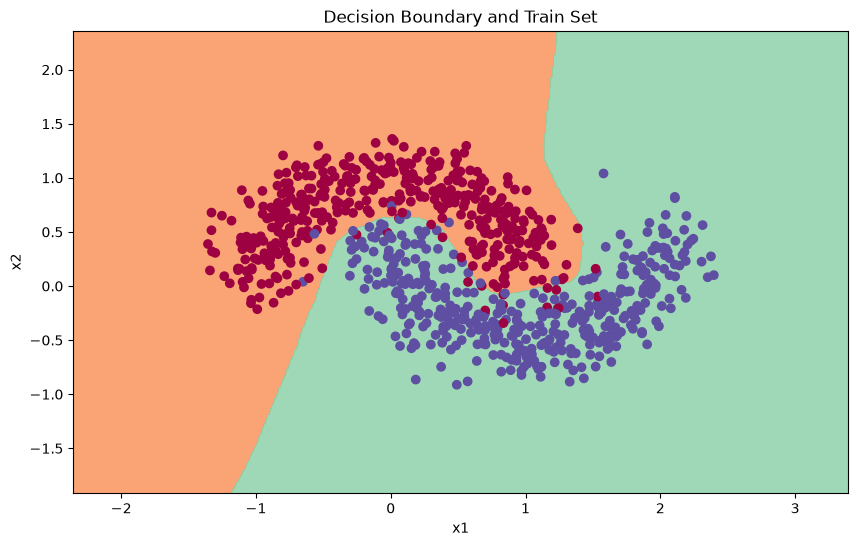

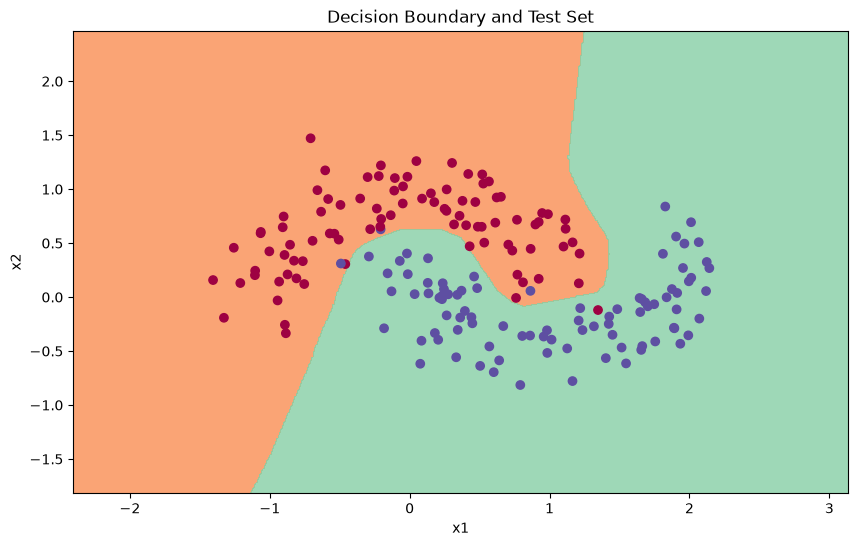

In [26]:
plot_decision_boundary(model, X_train, y_train, name="Train Set")
plot_decision_boundary(model, X_test, y_test, name="Test Set")
plt.show()